# TO DO
- Add: Identify placement areas (last section of old 01_placement_algorithm)

# Introduction

This notebook demonstrates how to use GLAES to systematically place objects (such as wind turbines) within a predefined study area.

### Workflow Overview:
1) **Create** file with available lands like in 00_basic_workflow_new. 
2) **Distribute item placements** within the eligible regions
    *  basic placement
    *  spare the edges of a region
    *  Direction-dependent placements
    *  Get placement coordinates
3) **Save** the resulting placements as a vector file.

In [1]:
# Import GLAES
import glaes as gl

%matplotlib inline

#other imports
from copy import copy

# 1. Create the land eligibility analysis from 00_basic_workflow_new

Here the eligibile land file from the first example notebook is recreated, for details have a look into 00_basic_workflow_new.

Memory usage during calc: 146.4140625 MB
Memory usage during calc: 147.453125 MB
Memory usage during calc: 178.96484375 MB


<Axes: >

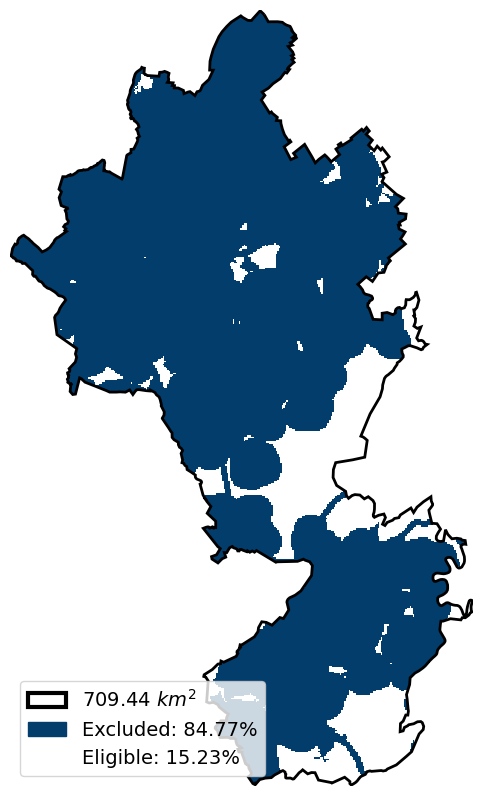

In [2]:
# Choose a region to operate on (Here, a predefined region for Aachen, Germany is used)
regionPath = gl._test_data_["aachenShapefile.shp"]

# Initialize ExclusionCalculator object
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# Apply exclusions
ec.excludeRasterType(gl._test_data_["clc-aachen_clipped.tif"], value=(12,22))
ec.excludeRasterType(gl._test_data_["clc-aachen_clipped.tif"], value=(1, 2), buffer=1000)
ec.excludeVectorType(gl._test_data_["aachenRoads.shp"], where="type='motorway' OR type='primary' OR type='trunk'", buffer=200)

# Draw result
ec.draw()

Copy the file from the land eligibility analysis to have a backup file.

In [3]:
# make a copy of the ec object so we can "reset" the ec object after distributing placements and have a "clean" ec again
ec_backup = copy(ec)

# 2. Distribute item placements within the eligible regions

### Basic Placement 
"Seperation" specifies the minimal distance between two objects.

<Axes: >

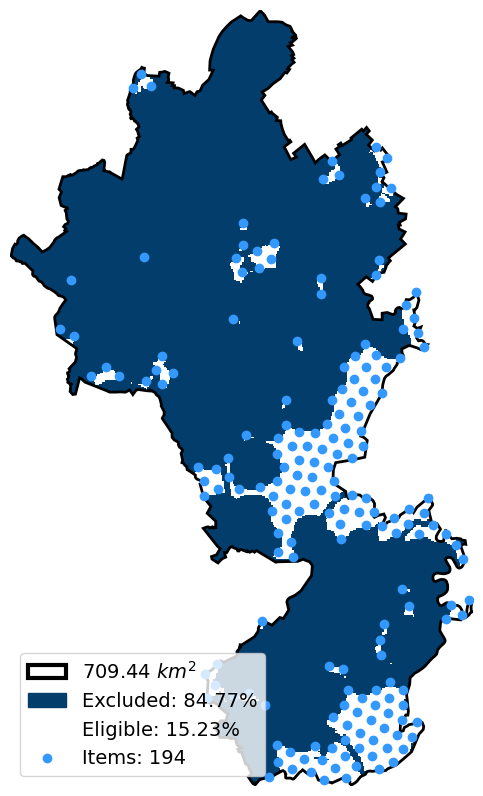

In [4]:
# Do placements
ec.distributeItems(separation=1000)

# Draw result
ec.draw()

### Spare the edges of a region  
Sometimes it is needed to spare the edges of a region so that the separation distances are maintained also between placements of neighbouring regions (avoidRegionBorders=True).

Memory usage during calc: 172.68359375 MB


<Axes: >

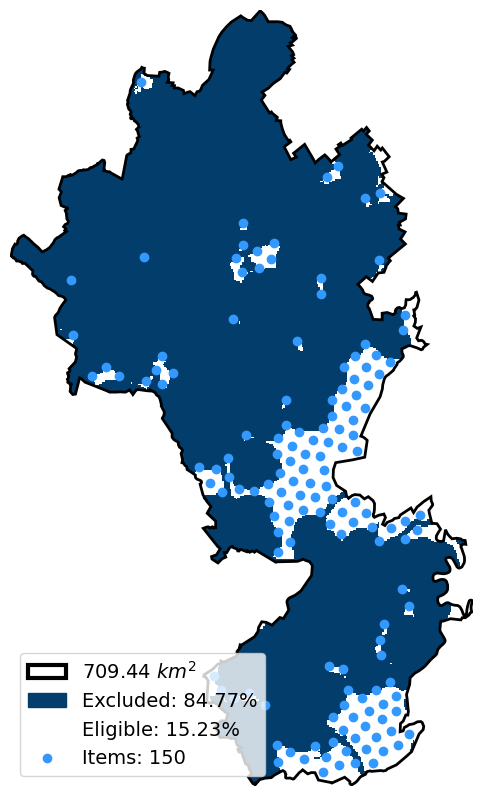

In [5]:
# reset the ec object to remove the "old" placements from above
ec = copy(ec_backup)
# repeat the step above and set the argument avoidRegionBorders to True
ec.distributeItems(separation=1000, avoidRegionBorders=True)

# Draw result. In comparison to above you can see that no placements are distributed towards the edges of the region, you can also see that less items were distributed
ec.draw()

### Direction-dependent placements  
If two different separation distances are defined, they represent the minimum required spacing between two objects along two perpendicular directions: an **axial** direction and a **transverse** direction.
The **axialDirection** parameter specifies the orientation of the axial axis in degrees, measured counter-clockwise relative to East.
When both axial and transverse distances are provided, the effective buffer distance applied at the boundary is the average of the two separation distances.

450
Memory usage during calc: 176.54296875 MB


<Axes: >

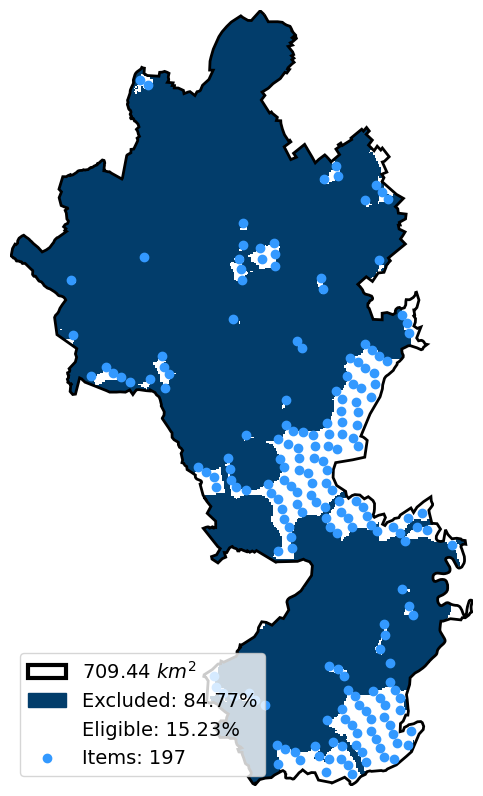

In [6]:
# reset the ec object again
ec = copy(ec_backup)
# do placements with "seperation=(axial, transverse), axialDirection"
ec.distributeItems(separation=(1200, 600), axialDirection=45, avoidRegionBorders=True)

# Draw result
ec.draw()

### Get the placements as XY coordinates

In [7]:
#print only the first 5 placements
print(ec.itemCoords[:5])

[[4045800.01 3095599.99]
 [4046350.   3095300.01]
 [4058700.01 3089999.99]
 [4058799.99 3089300.01]
 [4057900.01 3089100.01]]


# 3. Save the resulting placements as a vector file

In [8]:
# reset the ec object again
ec = copy(ec_backup)
# do placements with "seperation=(axial, transverse), axialDirection"
ec.distributeItems(separation=(1200, 600), axialDirection=45, avoidRegionBorders=True, output="tmp/aachen_placements.shp")

450
Memory usage during calc: 178.3359375 MB


Additionally the hole area can be divided into one aera for each placement and those can be saved as well.
'asArea=True' invokes the identification of nearby eligible areas using Voronoi ploygons.

In [ ]:
# reset the ec object again
ec = copy(ec_backup)
# do placements, get aligning areas and save areas
ec.distributeItems(separation=1000, asArea=True, output="tmp/aachen_placement_areas.shp")

# Draw result
ec.draw()

AssertionError: All outerRing entries must be (x,y) tuples in given (or default) srs.